<a href="https://colab.research.google.com/github/Surhan-Memon/Telco-Customer-Churn/blob/main/Telco_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


<Axes: xlabel='Churn', ylabel='count'>

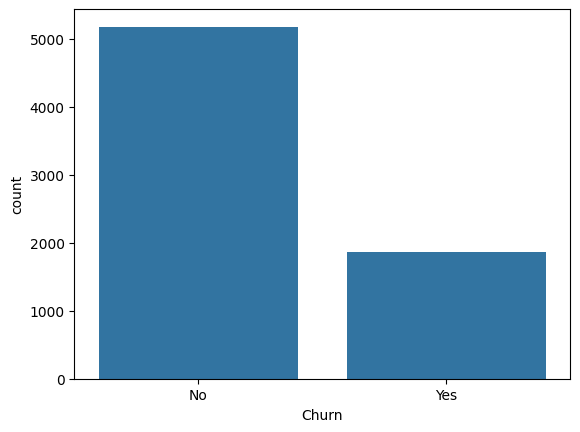

In [7]:
sns.countplot(data=df,x='Churn')

In [10]:
print((df['TotalCharges'] == ' ').sum())

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remove rows with missing values
df = df.dropna()

# Verify datatype
print(df['TotalCharges'].dtype)

11
float64


<Axes: xlabel='Churn', ylabel='TotalCharges'>

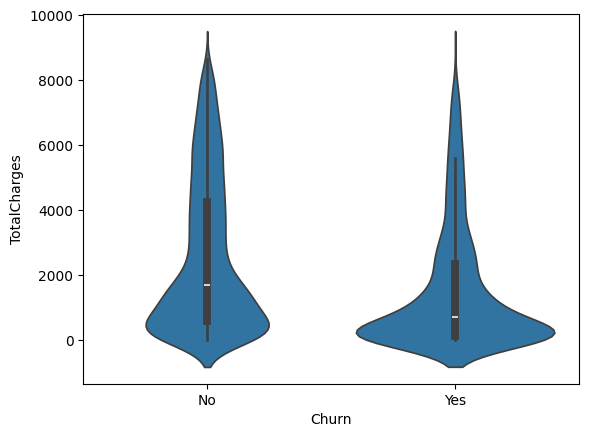

In [11]:
sns.violinplot(data=df, x='Churn', y='TotalCharges')

<Axes: xlabel='Churn', ylabel='TotalCharges'>

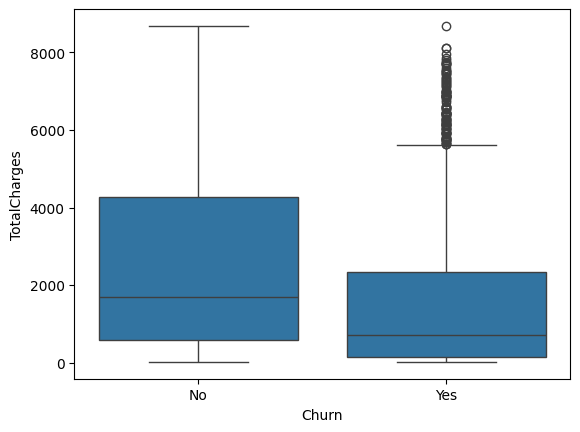

In [12]:
sns.boxplot(data=df, x='Churn', y='TotalCharges')

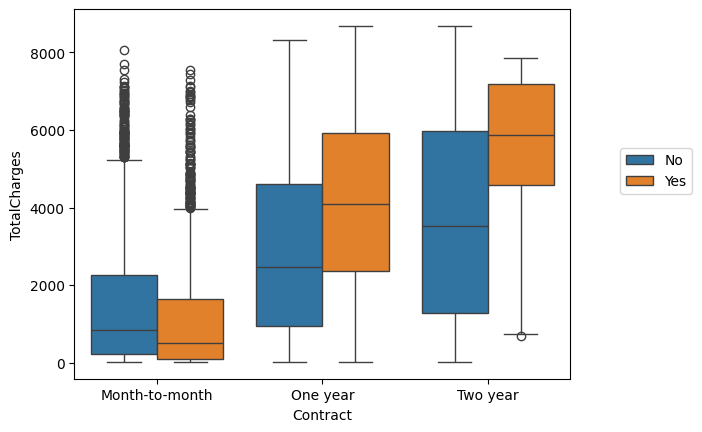

In [14]:
sns.boxplot(data=df, y='TotalCharges', x='Contract', hue='Churn')
plt.legend(loc=(1.1,0.5))

In [16]:
corr_df = pd.get_dummies(df[['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                             'DeviceProtection', 'TechSupport', 'InternetService', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
                             'PaymentMethod', 'Churn']]).corr()

In [20]:
corr_yes_churn = corr_df['Churn_Yes'].sort_values().iloc[1:-1]

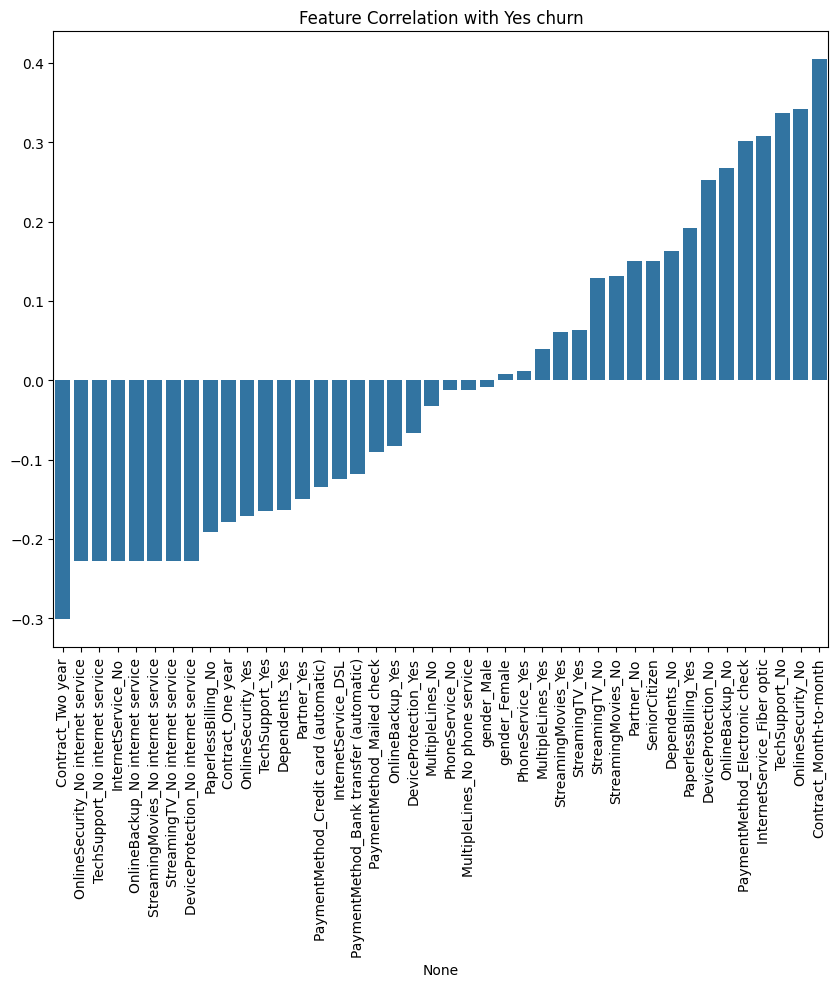

In [24]:
plt.figure(figsize=(10,8))
sns.barplot(x=corr_yes_churn.index, y=corr_yes_churn.values)
plt.title('Feature Correlation with Yes churn')
plt.xticks(rotation=90);

In [25]:
df['tenure'].unique()

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26, 39])

<Axes: xlabel='tenure', ylabel='Count'>

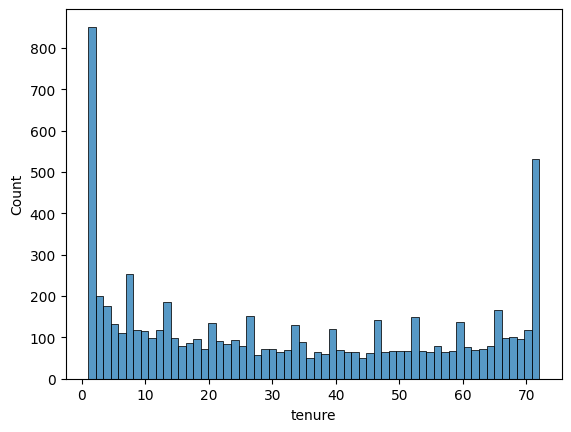

In [26]:
sns.histplot(data=df, x='tenure', bins=60)

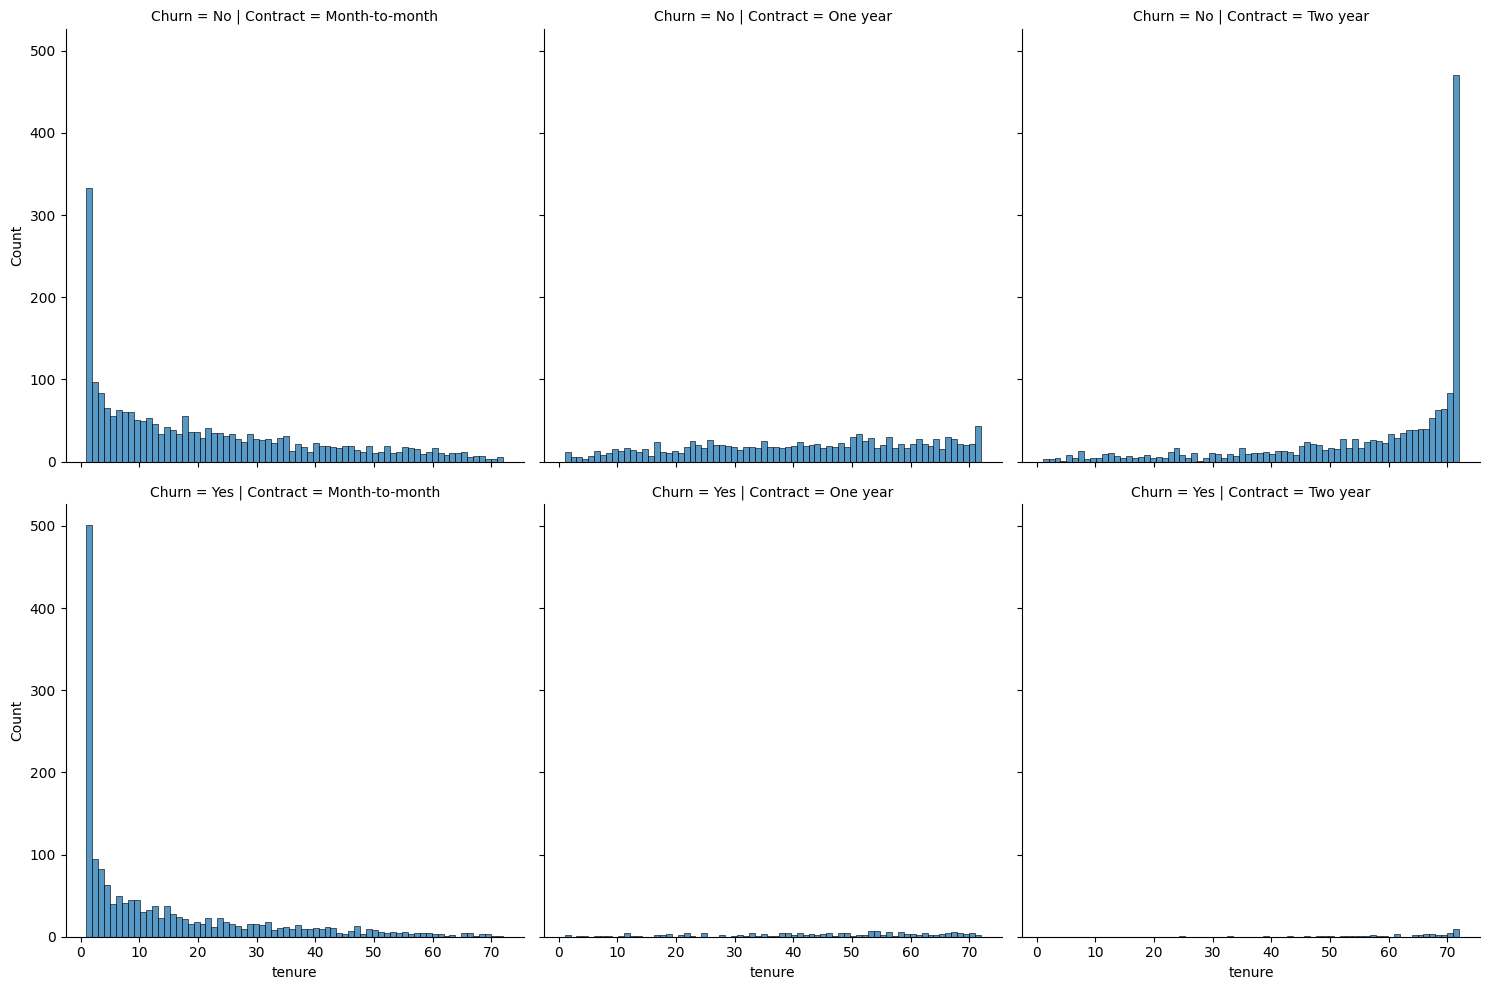

In [28]:
sns.displot(data=df, x='tenure', bins=70, col='Contract', row='Churn')

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

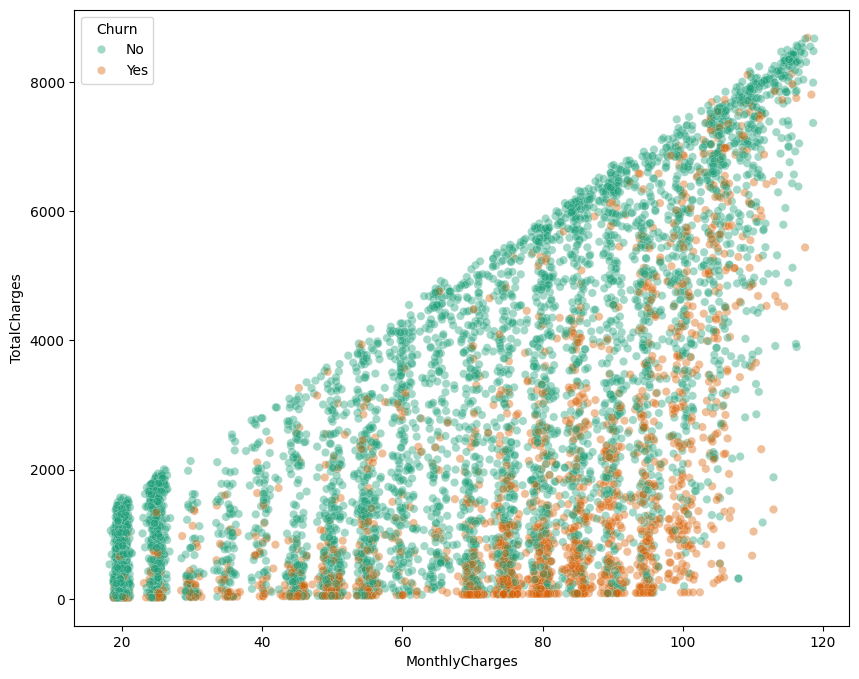

In [36]:
plt.figure(figsize =(10,8))
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges', hue='Churn', alpha=0.4, linewidth=0.3, palette='Dark2')

In [37]:
yes_churn = df.groupby(['Churn', 'tenure']).count().transpose()['Yes']

In [38]:
no_churn = df.groupby(['Churn', 'tenure']).count().transpose()['No']

In [40]:
churn_rate = 100*yes_churn/(yes_churn+no_churn)

In [42]:
churn_rate.transpose()['customerID']

,customerID
tenure,
1,61.990212
2,51.680672
3,47.000000
4,47.159091
5,48.120301
...,...
68,9.000000
69,8.421053
70,9.243697


<Axes: xlabel='tenure'>

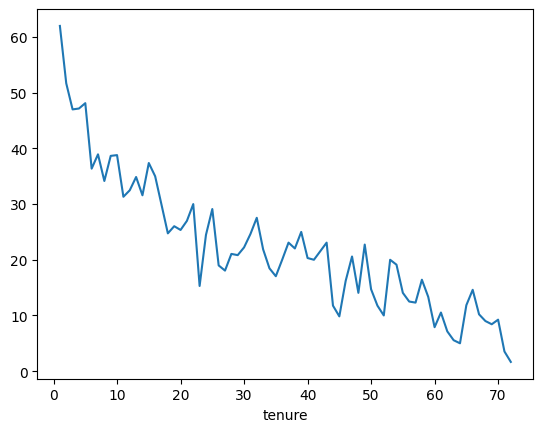

In [43]:
churn_rate.transpose()['customerID'].plot()

In [44]:
def cohort(tenure):
  if tenure < 13:
    return '0-12 Months'
  elif tenure < 25:
    return '12-24 Months'
  elif tenure < 49:
    return '24-48 Months'
  else:
    return 'Over 48 Months'

In [45]:
df['Tenure cohort'] = df['tenure'].apply(cohort)

In [46]:
df[['Tenure cohort', 'tenure']]

,Tenure cohort,tenure
0,0-12 Months,1
1,24-48 Months,34
2,0-12 Months,2
3,24-48 Months,45
4,0-12 Months,2
...,...,...
7038,12-24 Months,24
7039,Over 48 Months,72
7040,0-12 Months,11
7041,0-12 Months,4


<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

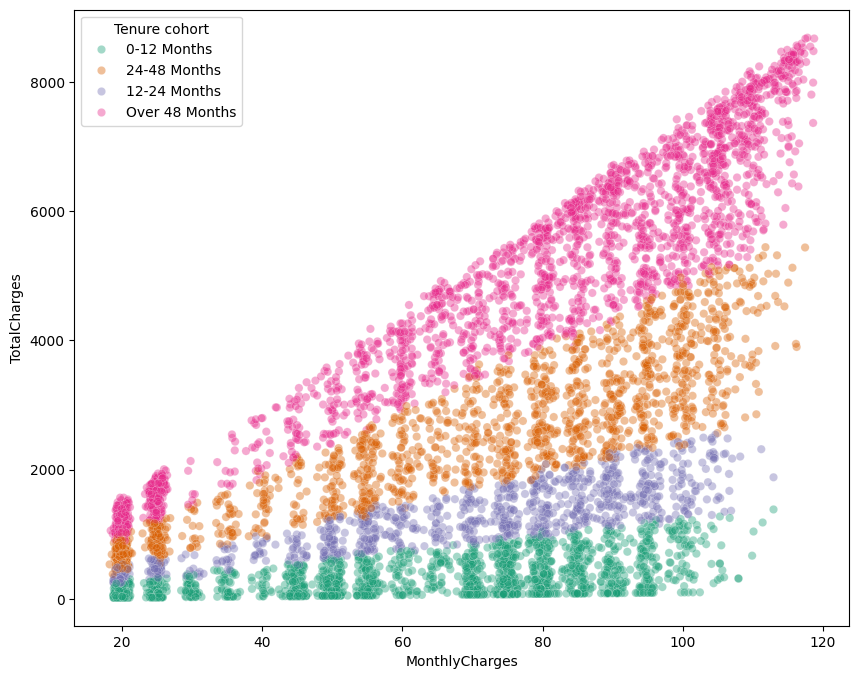

In [47]:
plt.figure(figsize =(10,8))
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges', hue='Tenure cohort', alpha=0.4, linewidth=0.3, palette='Dark2')

<Axes: xlabel='Tenure cohort', ylabel='count'>

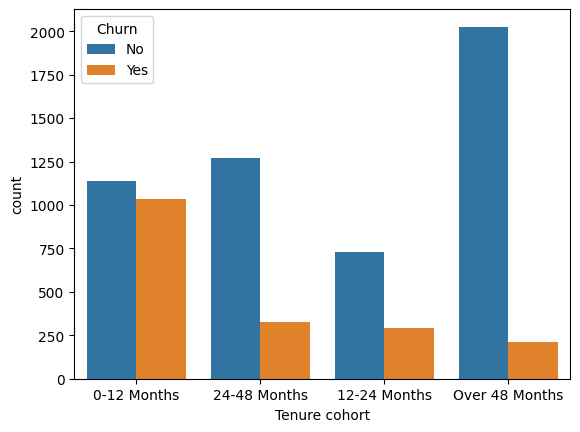

In [48]:
sns.countplot(data=df, x='Tenure cohort', hue='Churn')

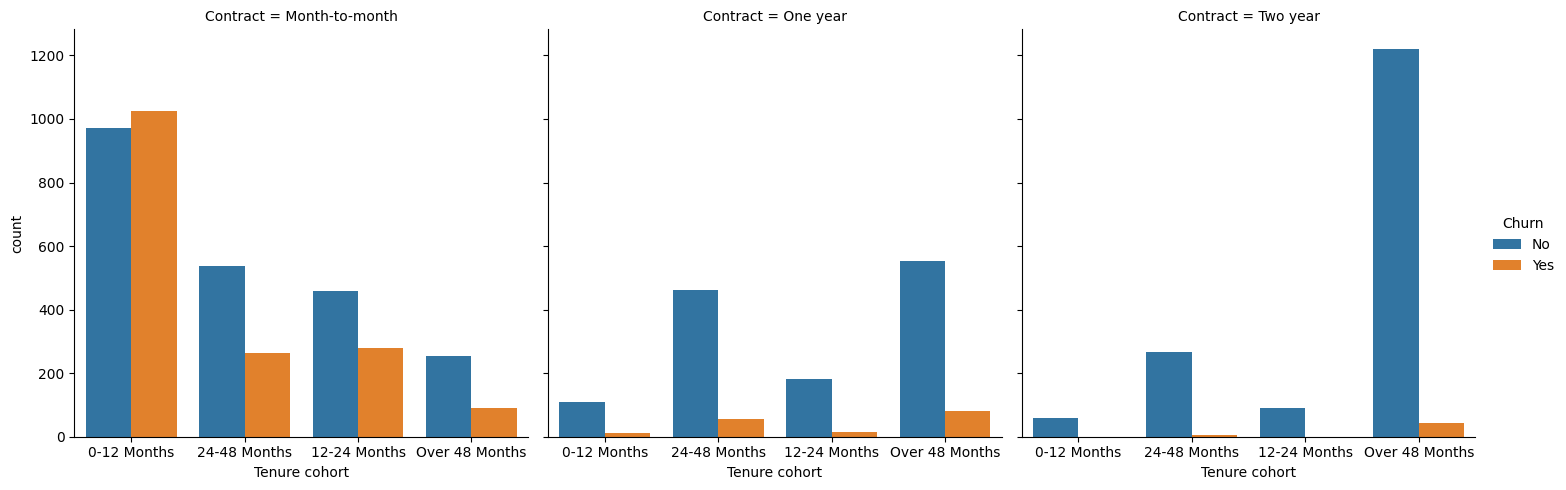

In [51]:
sns.catplot(data=df,x='Tenure cohort', hue='Churn', kind='count', col='Contract')

In [52]:
X = df.drop(['Churn', 'customerID'], axis=1)

In [53]:
X = pd.get_dummies(X, drop_first=True)

In [54]:
y = df['Churn']

In [55]:
from sklearn.model_selection import train_test_split

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

In [77]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier

In [58]:
dt = DecisionTreeClassifier(max_depth=6)

In [59]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6)

In [60]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [61]:
preds = dt.predict(X_test)

In [62]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

          No       0.87      0.89      0.88       557
         Yes       0.55      0.49      0.52       147

    accuracy                           0.81       704
   macro avg       0.71      0.69      0.70       704
weighted avg       0.80      0.81      0.81       704



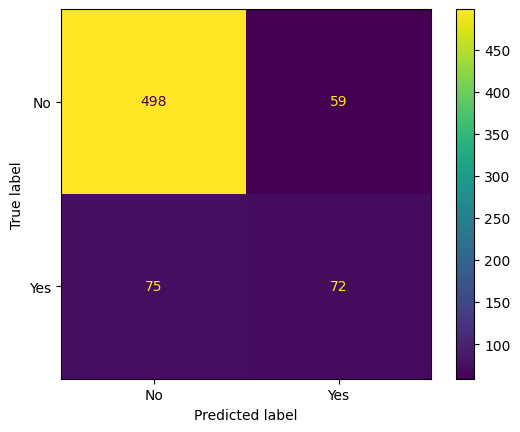

In [64]:
cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm, display_labels=dt.classes_).plot()

In [66]:
imp_feats = pd.DataFrame(dt.feature_importances_, index=X.columns, columns=['feat Imp'])

In [70]:
imp_feats = imp_feats.sort_values('feat Imp')
imp_feats = imp_feats[imp_feats['feat Imp'] > 0]
imp_feats

,feat Imp
PhoneService_Yes,0.000890
gender_Male,0.001237
OnlineBackup_Yes,0.005341
MultipleLines_No phone service,0.006962
TechSupport_Yes,0.007868
OnlineSecurity_Yes,0.008376
Contract_One year,0.010021
MultipleLines_Yes,0.012432
SeniorCitizen,0.012680
OnlineSecurity_No internet service,0.026290


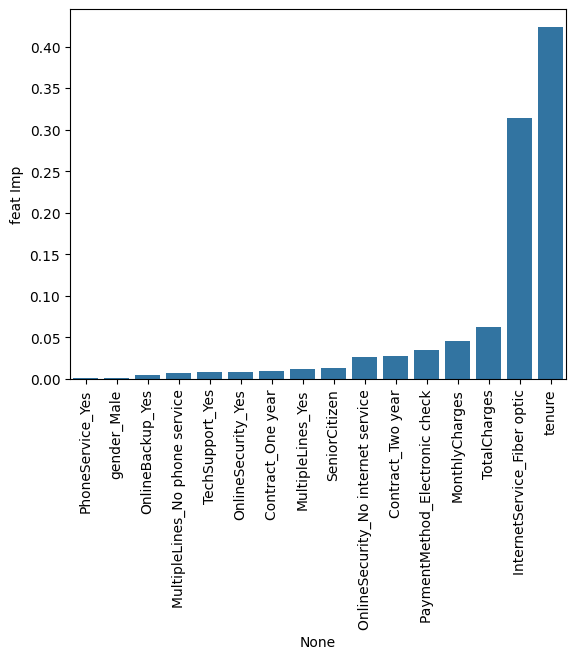

In [72]:
sns.barplot(data=imp_feats, x=imp_feats.index, y=imp_feats['feat Imp'])
plt.xticks(rotation=90);

In [73]:
from sklearn.tree import plot_tree

In [76]:
#plot_tree(dt);

In [78]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

In [93]:
rf = RandomForestClassifier()

In [94]:
rf.fit(X_train, y_train)

RandomForestClassifier()

In [95]:
preds = rf.predict(X_test)

In [96]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

          No       0.86      0.88      0.87       557
         Yes       0.50      0.46      0.48       147

    accuracy                           0.79       704
   macro avg       0.68      0.67      0.67       704
weighted avg       0.78      0.79      0.79       704



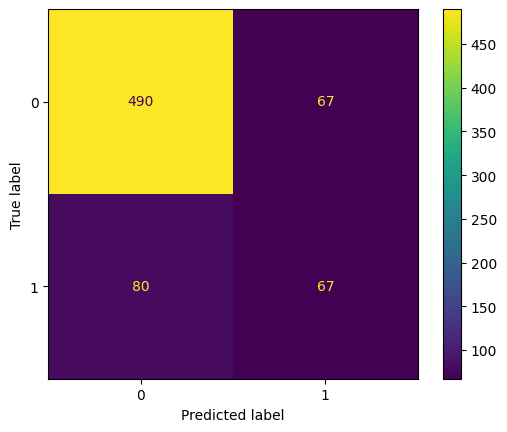

In [97]:
cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm).plot()

In [98]:
#Boosting
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier

In [108]:
ada_model = AdaBoostClassifier(n_estimators=100)

In [100]:
gb_model = GradientBoostingClassifier()

In [109]:
ada_model.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=100)

In [102]:
gb_model.fit(X_train, y_train)

GradientBoostingClassifier()

In [110]:
ada_preds = ada_model.predict(X_test)

In [104]:
gb_preds = gb_model.predict(X_test)

In [111]:
print(classification_report(y_test, ada_preds))

              precision    recall  f1-score   support

          No       0.88      0.92      0.90       557
         Yes       0.62      0.50      0.56       147

    accuracy                           0.83       704
   macro avg       0.75      0.71      0.73       704
weighted avg       0.82      0.83      0.83       704



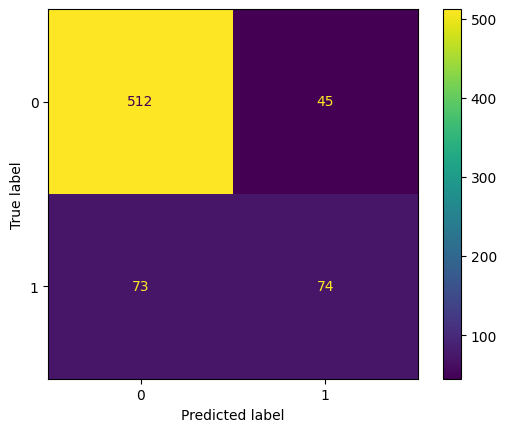

In [112]:
cm = confusion_matrix(y_test, ada_preds)
ConfusionMatrixDisplay(cm).plot()

In [106]:
print(classification_report(y_test, gb_preds))

              precision    recall  f1-score   support

          No       0.87      0.90      0.89       557
         Yes       0.57      0.50      0.53       147

    accuracy                           0.82       704
   macro avg       0.72      0.70      0.71       704
weighted avg       0.81      0.82      0.81       704

